In [ ]:
# env is norm_scRNAseq

In [ ]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from scipy.stats import gamma
import os
import glob

import gzip
import scipy.io

In [ ]:
#### contamination fraction for all samples

In [ ]:
metrics_dir = "../../data/out_ambientRNA/metrics"
os.makedirs("../plots", exist_ok=True)

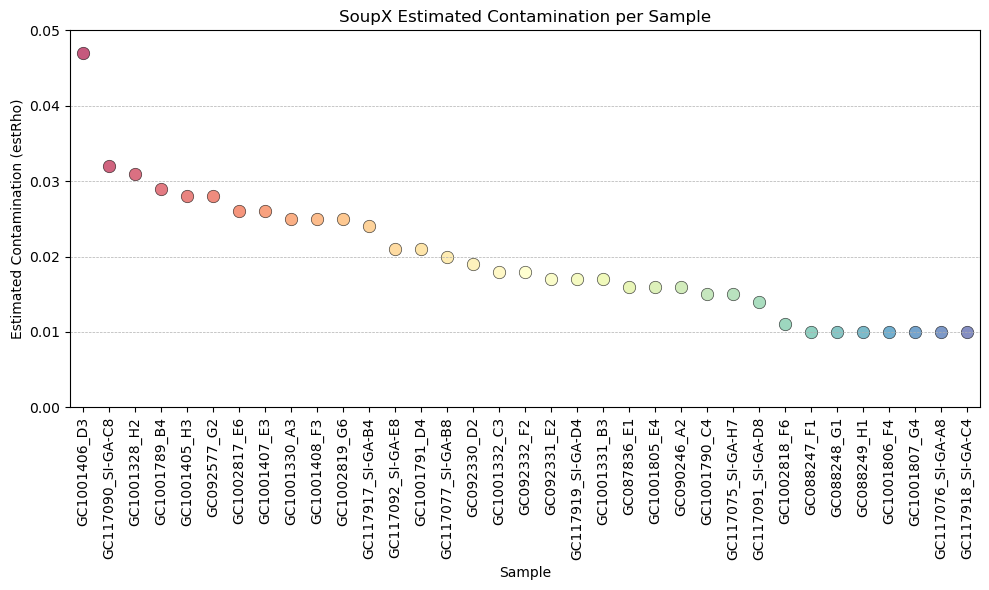

In [ ]:
rho_files = sorted(glob.glob(os.path.join(metrics_dir, "*_soupx_rho.txt")))

data = []
for file in rho_files:
    sample = os.path.basename(file).replace("_soupx_rho.txt", "")
    try:
        with open(file, "r") as f:
            value = f.read().strip()
            if value:
                est_rho = float(value)
                data.append({"Sample": sample, "estRho": est_rho})
            else:
                print(f"⚠️ Empty file: {file}")
    except Exception as e:
        print(f"⚠️ Error reading {file}: {e}")

if data:
    df = pd.DataFrame(data)
    df = df.sort_values("estRho", ascending=False).reset_index(drop=True)

    n_samples = len(df)
    colors = sns.color_palette("Spectral", n_colors=n_samples)

    plt.figure(figsize=(10, 6))
    for i, (sample, est_rho) in enumerate(zip(df["Sample"], df["estRho"])):
        plt.scatter(i, est_rho, color=colors[i], edgecolor='black', alpha=0.7, linewidth=0.5, s=80)

    plt.xlim(-0.5, n_samples - 0.5)
    plt.ylim(0, 0.05)

    plt.xticks(ticks=range(n_samples), labels=df["Sample"], rotation=90)
    plt.xlabel("Sample")
    plt.ylabel("Estimated Contamination (estRho)")
    plt.title("SoupX Estimated Contamination per Sample")
    plt.grid(axis="y", linestyle="--", linewidth=0.5)

    plt.tight_layout()
    plt.savefig("../plots/soupx_rho.png", dpi=300)
    plt.show()
else:
    print("⚠️ No estRho values")


In [ ]:
# save the df for sample order by estrho

In [24]:
display(df)

,Sample,estRho
14,GC1001406_D3,0.047
29,GC117090_SI-GA-C8,0.032
9,GC1001328_H2,0.031
17,GC1001789_B4,0.029
13,GC1001405_H3,0.028
8,GC092577_G2,0.028
23,GC1002817_E6,0.026
15,GC1001407_E3,0.026
10,GC1001330_A3,0.025
16,GC1001408_F3,0.025


In [25]:
df = df.reset_index(drop=True)

In [27]:
df.to_csv("samples_ordered.csv", index = True)